In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Check GPU availability
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available")

GPU is available


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Load FashionMNIST dataset
def load_data():
    (train_data, test_data), info = tfds.load(
        "fashion_mnist",
        split=["train", "test"],
        shuffle_files=True,
        as_supervised=True,
        with_info=True
    )
    return train_data, test_data, info

# Preprocess the dataset (resize & normalize)
def preprocess(image, label):
    image = tf.image.resize(image, (28, 28)) / 255.0  # Normalize
    image = tf.expand_dims(image, axis=-1)  # Ensure shape (28, 28, 1)
    label = tf.one_hot(label, depth=10)  # 10 classes for FashionMNIST
    return image, label

# Prepare the datasets
def prepare_datasets(train_data, test_data):
    train_data = train_data.map(preprocess).batch(64).prefetch(tf.data.AUTOTUNE)
    test_data = test_data.map(preprocess).batch(64).prefetch(tf.data.AUTOTUNE)
    return train_data, test_data


In [ ]:
# CNN Model 1
def build_cnn_1(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# # CNN Model 2
# def build_cnn_2(input_shape, num_classes):
#     model = models.Sequential([
#         layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(64, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(128, (3, 3), activation='relu'),
#         layers.Conv2D(128, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),
#         layers.Flatten(),
#         layers.Dense(128, activation='relu'),
#         layers.Dense(256, activation='relu'),
#         layers.Dense(num_classes, activation='softmax')
#     ])
#     return model

# CNN Model 3
# def build_cnn_3(input_shape, num_classes):
#     model = models.Sequential([
#         layers.Input(shape=input_shape),
#         layers.Conv2D(32, (3, 3), activation='relu', padding="same"),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
#         layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
#         layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
#         layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
#         layers.MaxPooling2D((2, 2)),
#         layers.Flatten(),
#         layers.Dense(128, activation='relu'),
#         layers.Dense(256, activation='relu'),
#         layers.Dense(num_classes, activation='softmax')
#     ])
#     return model

In [ ]:
# Train the model
def train_model(model, train_data, test_data, optimizer):
    print(f"\nUsing optimizer: {optimizer}")

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = {
        'loss': [],
        'accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }

    for epoch in range(30):
        print(f"Epoch {epoch + 1}/30")

        # Training phase
        history_epoch = model.fit(
            train_data,
            validation_data=test_data,
            epochs=1
        )

        # Store history
        history['loss'].append(history_epoch.history['loss'][0])
        history['accuracy'].append(history_epoch.history['accuracy'][0])
        history['val_loss'].append(history_epoch.history['val_loss'][0])
        history['val_accuracy'].append(history_epoch.history['val_accuracy'][0])

    return model, history


# List of optimizers (all with lr=0.001)
optimizers = [
    tf.keras.optimizers.SGD(learning_rate=0.01),
    tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    tf.keras.optimizers.RMSprop(learning_rate=0.001),
    tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    tf.keras.optimizers.Adagrad(learning_rate=0.001),
    tf.keras.optimizers.Adadelta(learning_rate=0.001, rho=0.95),
    tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=True)
]

# Load and prepare data
train_data, test_data, info = load_data()
train_data, test_data = prepare_datasets(train_data, test_data)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.2U4VCB_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.2U4VCB_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:
# Define readable optimizer names
optimizer_names = [
    "SGD",
    "SGD + Momentum",
    "RMSProp",
    "Adam",
    "Adagrad",
    "Adadelta",
    "Adamax",
    "Nadam",
    "Adam AMSGrad"
]

# Function to plot results for multiple optimizers (accuracy and loss)
def plot_results(histories, optimizers):
    plt.figure(figsize=(12, 6))

    colors = [
        'black', 'blue', 'gray', 'red', 'yellow', 'green',
        'purple', 'cyan', 'magenta', 'orange', 'brown'
    ]

    # Plot accuracy
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, plot 1st subplot
    for i, opt in enumerate(optimizers):
        plt.plot(histories[i]['accuracy'], label=opt, color=colors[i])
    plt.xticks(range(0, len(histories[0]['accuracy']), 5))
    plt.xlabel("Epochs")
    plt.ylabel("Training Accuracy")
    plt.title("Training Accuracy per Optimizer")
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, plot 2nd subplot
    for i, opt in enumerate(optimizers):
        plt.plot(histories[i]['loss'], label=opt, color=colors[i])
    plt.xticks(range(0, len(histories[0]['loss']), 5))
    plt.xlabel("Epochs")
    plt.ylabel("Training Loss")
    plt.title("Training Loss per Optimizer")
    plt.legend()

    plt.tight_layout()
    plt.show()

## CNN-1 Result

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Using optimizer: <keras.src.optimizers.sgd.SGD object at 0x7c0e7d7ecb10>
Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.2805 - loss: 1.9757 - val_accuracy: 0.6450 - val_loss: 0.8925
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6945 - loss: 0.8110 - val_accuracy: 0.6786 - val_loss: 0.7858
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7426 - loss: 0.6863 - val_accuracy: 0.7200 - val_loss: 0.7208
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7713 - loss: 0.6192 - val_accuracy: 0.7486 - val_loss: 0.6720
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7896 - loss: 0.5739 - val_accuracy: 0.7627 - val_loss: 0.6358
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8033 - loss: 0.5403 - val_accuracy: 0.7761 - val_loss: 0.6049
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8129 - loss: 0.5141 - val_accuracy: 0.7875 - val_loss: 0.5791
Epoch 8/30
938/938 ━━━━━━━━━

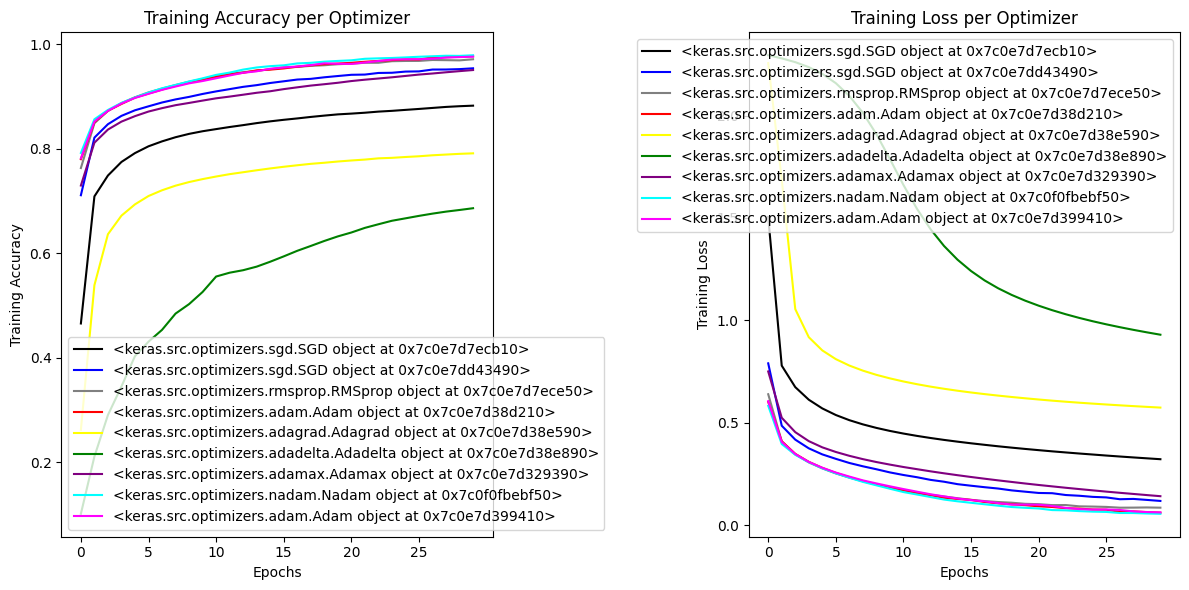

In [ ]:
histories = []
for optimizer in optimizers:
    model = build_cnn_1(input_shape=(28, 28, 1), num_classes=10)
    _, history = train_model(model, train_data, test_data, optimizer)
    histories.append(history)

plot_results(histories, optimizers)


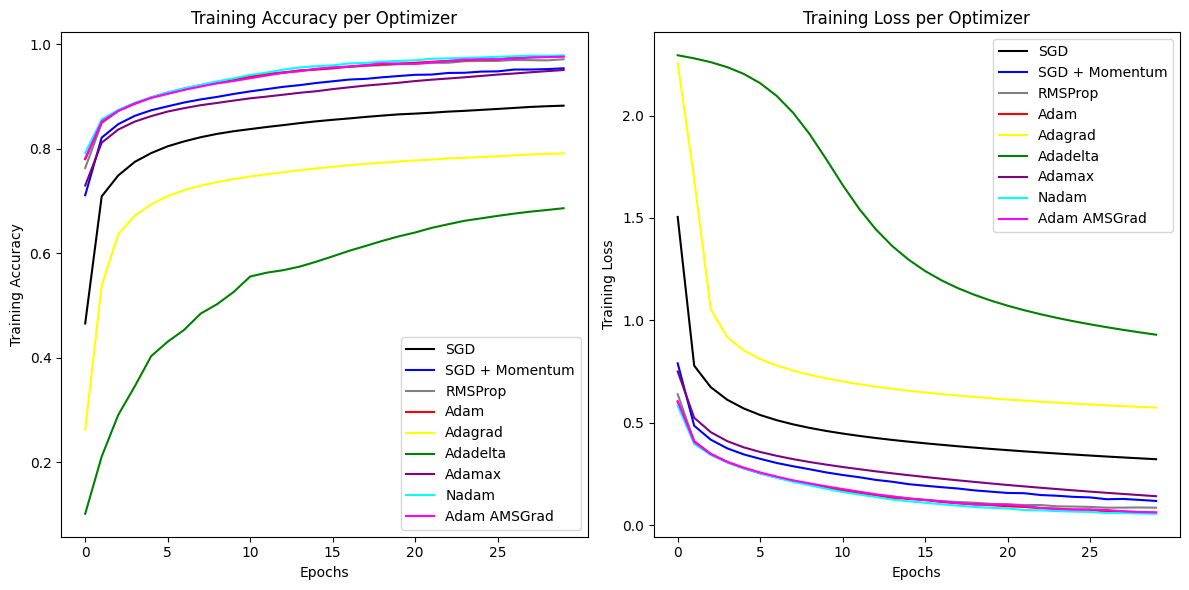

In [ ]:
plot_results(histories, optimizer_names)

## CNN-2 Result

In [ ]:
# Ensure eager execution is enabled
if not tf.executing_eagerly():
    tf.compat.v1.enable_eager_execution()



# CNN Model 2 - Keep original architecture with adjustments
def build_cnn_2(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),  # Add padding
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),  # Add padding
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),  # Add padding
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),  # Add padding
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Using optimizer: <keras.src.optimizers.sgd.SGD object at 0x7eb7c4b3ad50>
Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3960 - loss: 1.8460 - val_accuracy: 0.6648 - val_loss: 0.8194
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7412 - loss: 0.6865 - val_accuracy: 0.7439 - val_loss: 0.6715
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7941 - loss: 0.5595 - val_accuracy: 0.7893 - val_loss: 0.5610
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8221 - loss: 0.4869 - val_accuracy: 0.8131 - val_loss: 0.5064
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8379 - loss: 0.4417 - val_accuracy: 0.8233 - val_loss: 0.4803
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8512 - loss: 0.4099 - val_accuracy: 0.8308 - val_loss: 0.4518
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8597 - loss: 0.3856 - val_accuracy: 0.8354 - val_loss: 0.4393
Epoch 8/30
938/938 ━━━━━━━━━

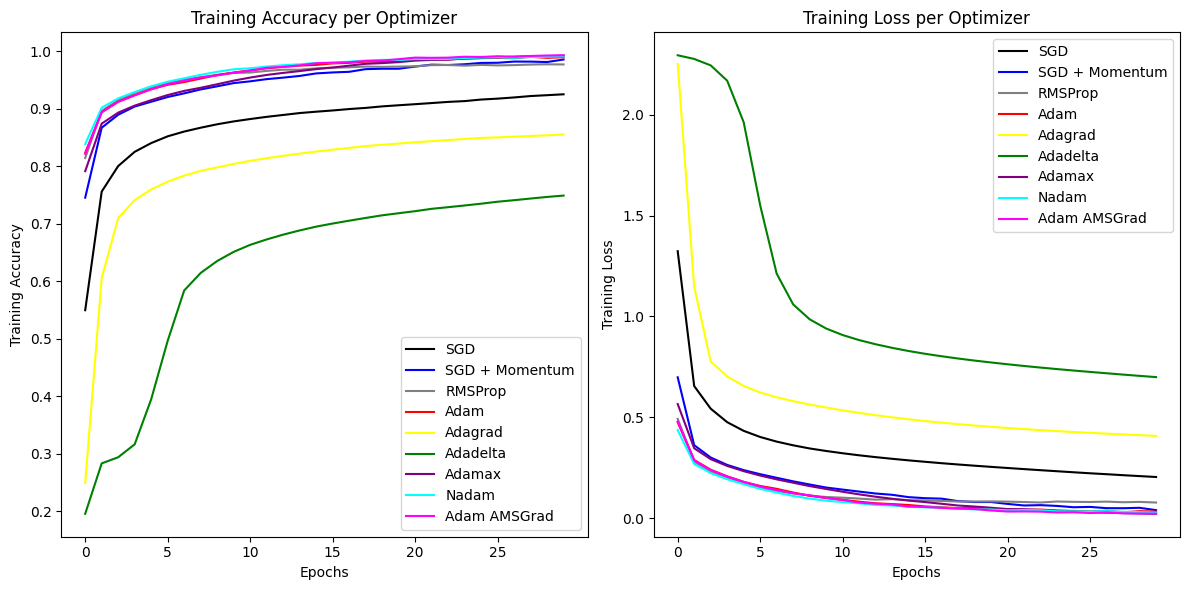

In [ ]:
histories = []
for optimizer in optimizers:
    model = build_cnn_2(input_shape=(28, 28, 1), num_classes=10)
    _, history = train_model(model, train_data, test_data, optimizer)
    histories.append(history)

plot_results(histories, optimizer_names)


## CNN-3 Result


Using optimizer: <keras.src.optimizers.sgd.SGD object at 0x7c8bd748be50>
Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.2987 - loss: 1.9749 - val_accuracy: 0.6277 - val_loss: 0.8603
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7451 - loss: 0.6732 - val_accuracy: 0.7802 - val_loss: 0.5984
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8047 - loss: 0.5334 - val_accuracy: 0.7992 - val_loss: 0.5421
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8313 - loss: 0.4639 - val_accuracy: 0.8024 - val_loss: 0.5231
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8467 - loss: 0.4209 - val_accuracy: 0.8072 - val_loss: 0.5100
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8558 - loss: 0.3927 - val_accuracy: 0.8172 - val_loss: 0.4945
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8636 - loss: 0.3726 - val_accuracy: 0.8120 - val_loss: 0.4994
Epoch 8/30
938/938 ━━━━━━━━━

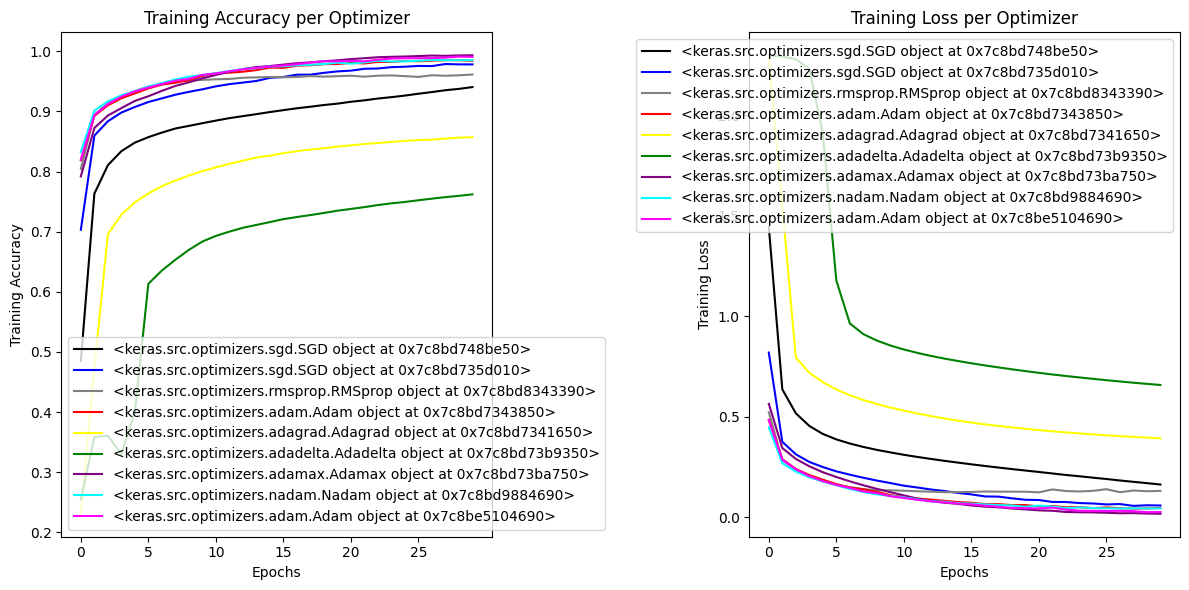

In [ ]:
# Ensure eager execution is enabled
if not tf.executing_eagerly():
    tf.compat.v1.enable_eager_execution()


def build_cnn_3(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
        layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
        layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
        layers.Conv2D(128, (3, 3), activation='relu', padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


histories = []
for optimizer in optimizers:
    model = build_cnn_3(input_shape=(28, 28, 1), num_classes=10)
    _, history = train_model(model, train_data, test_data, optimizer)
    histories.append(history)

plot_results(histories, optimizers)


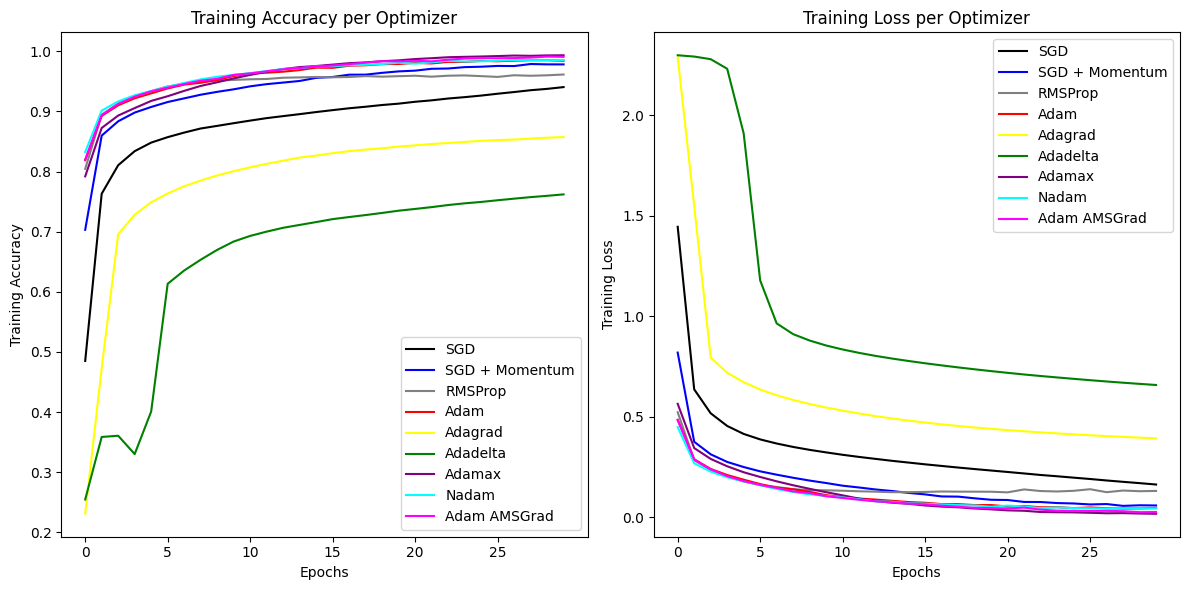

In [ ]:
plot_results(histories, optimizer_names)